# TP Final - Du dataset au modèle déployé

**Formation Machine Learning & Data Science - Jour 3**

Ce notebook couvre les parties A, B et C du TP : chargement des données, choix des variables
sans fuite, construction du pipeline scikit-learn, évaluation, sauvegarde et interrogation du modèle.
La partie D (interface) est dans `app.py`, la partie E (déploiement) dans le `README.md`.

*Auteur : FEUMBA RUDY CARLIER  ·  Date : 19/06/2026*

---
# PARTIE A - Chargement & choix des variables

Objectif : préparer X et y sans tricher (sans fuite de données).

In [4]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

import os
os.makedirs('data', exist_ok=True); os.makedirs('models', exist_ok=True)

## Étape 1 - Charger le fichier Excel et le convertir en CSV

In [5]:
df = pd.read_excel('../data/dataset_assurance_ML.xlsx')
df.to_csv('data/dataset_assurance_ML.csv', index=False, encoding='utf-8-sig')
df = pd.read_csv('data/dataset_assurance_ML.csv', encoding='utf-8-sig')
print(df.shape)
print('Manquants :', df.isnull().sum().sum(), '| Doublons :', df.duplicated().sum())
df.head()

(500, 27)
Manquants : 0 | Doublons : 0


,N° Police,Nom,Prénom,Sexe,Âge,Catégorie Prof.,Salaire Annuel (€),Ville,Code Postal,Type Contrat,...,Type Véhicule,Usage Véhicule,Puissance Fiscale (CV),Valeur Véhicule (€),Coeff. Bonus-Malus,Nb Sinistres (3 ans),Montant Sinistres (€),Dernier Sinistre,Score Risque (0-100),Résiliation
0,ASS01000,Bernard,Valérie,F,56,Profession libérale,76288,Nice,6200,Gold,...,SUV,Loisirs,9,20108,0.80,1,1447,Dégât des eaux,12,0
1,ASS01001,Simon,Éric,H,69,Employé,30020,Paris,75018,Bronze,...,SUV,Loisirs,9,29845,1.02,1,685,Incendie,20,0
2,ASS01002,Lambert,Inès,F,46,Technicien,36995,Lyon,69009,Silver,...,Citadine,Domicile-Travail,4,19035,0.54,0,0,Aucun,0,0
3,ASS01003,Blanc,François,H,32,Profession libérale,64773,Bordeaux,33200,Gold,...,Berline,Loisirs,8,25765,0.90,1,0,Vol,28,1
4,ASS01004,Vincent,Patrick,H,60,Cadre,69870,Nantes,44200,Gold,...,Berline,Loisirs,7,24365,0.96,1,0,Incendie,7,0


## Étape 2 - La variable cible

In [6]:
TARGET = 'Résiliation'
print(df[TARGET].value_counts())
print((df[TARGET].value_counts(normalize=True) * 100).round(1))

Résiliation
0    450
1     50
Name: count, dtype: int64
Résiliation
0    90.0
1    10.0
Name: proportion, dtype: float64


**Le problème est-il équilibré ?** Non : environ 10 % de résiliants contre 90 % de clients qui restent.
Conséquence pour l'entraînement : l'accuracy seule sera trompeuse (un modèle qui prédit toujours « 0 »
atteindrait déjà ~90 %), on utilisera `class_weight='balanced'` et on jugera avec le ROC-AUC et le F1,
pas l'accuracy seule.

## Étape 3 - Détecter une fuite de données (data leakage)

In [7]:
print(pd.crosstab(df['Statut Contrat'], df[TARGET]))

Résiliation       0   1
Statut Contrat         
Actif           450   0
Résilié           0  36
Suspendu          0  14


**Que remarque-t-on ?** Chaque modalité de `Statut Contrat` détermine la cible à 100 % :
`Actif` -> 0 résiliation, `Résilié` -> toutes résiliées, `Suspendu` -> un mélange qui reste
révélateur. Cette colonne **contient déjà la réponse** : elle n'est renseignée qu'une fois
la résiliation constatée, donc elle ne sera pas disponible au moment de la prédiction réelle.
**Elle est exclue du modèle.**

## Étape 4 - Choisir les variables numériques et catégorielles

In [8]:
num_cols = ['Âge', 'Salaire Annuel (€)', 'Prime Annuelle (€)', 'Ancienneté (mois)',
            'Coeff. Bonus-Malus', 'Nb Sinistres (3 ans)',
            'Montant Sinistres (€)', 'Score Risque (0-100)']
cat_cols = ['Type Contrat', 'Catégorie Prof.', 'Usage Véhicule', 'Dernier Sinistre']

X = df[num_cols + cat_cols]
y = df[TARGET]
print(X.shape, y.shape)

(500, 12) (500,)


## Étape 5 - Vérifier le lien avec la cible

In [9]:
print(X[num_cols].corrwith(y).round(3).sort_values(ascending=False))
print()
print(df.groupby('Dernier Sinistre')[TARGET].mean().round(2).sort_values())

Nb Sinistres (3 ans)     0.455
Score Risque (0-100)     0.441
Coeff. Bonus-Malus       0.412
Montant Sinistres (€)    0.284
Prime Annuelle (€)       0.041
Âge                     -0.006
Salaire Annuel (€)      -0.012
Ancienneté (mois)       -0.055
dtype: float64

Dernier Sinistre
Aucun                    0.03
Incendie                 0.16
Catastrophe naturelle    0.18
Accident                 0.26
Bris de glace            0.30
Vol                      0.30
Dégât des eaux           0.36
Name: Résiliation, dtype: float64


**Les 3 variables numériques les plus liées à la résiliation** (voir les corrélations ci-dessus) :
`Nb Sinistres (3 ans)`, `Score Risque (0-100)` et `Coeff. Bonus-Malus` — trois mesures de la
sinistralité et du risque perçu. Côté `Dernier Sinistre`, un sinistre de type Dégât des eaux ou Vol
porte le taux de résiliation bien au-dessus de la moyenne, contre un taux très faible sans sinistre.

---
# PARTIE B - Pipeline, entraînement & évaluation

Objectif : un seul objet qui fait TOUT, du brut à la prédiction.

## Étape 6 - Séparer train / test

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)
print(y_train.mean().round(2), y_test.mean().round(2))

(400, 12) (100, 12)
0.1 0.1


## Étape 7 - Le prétraitement en un seul objet : ColumnTransformer

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

## Étape 8 - Deux candidats dans un Pipeline

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

candidats = {
    'Régression Logistique': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=4, min_samples_leaf=10,
        class_weight='balanced', random_state=42),
}
pipelines = {nom: Pipeline([('prep', preprocessor), ('model', algo)])
             for nom, algo in candidats.items()}

## Étape 9 - Comparer par validation croisée

In [13]:
from sklearn.model_selection import cross_val_score

for nom, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')
    print(f'{nom:22s} AUC = {scores.mean():.3f} ± {scores.std():.3f}')

Régression Logistique  AUC = 0.745 ± 0.113
Random Forest          AUC = 0.801 ± 0.096


**Quel modèle retenir ?** Sur ce dataset, le Random Forest égale ou dépasse la régression
logistique et fournit en prime les importances de variables, précieuses pour expliquer une
prédiction à un conseiller. C'est le modèle retenu pour la suite.

## Étape 10 - Entraîner le modèle retenu et évaluer sur le test

In [14]:
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)

pipeline = pipelines['Random Forest']
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, y_pred), 3))
print('F1       :', round(f1_score(y_test, y_pred), 3))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_proba), 3))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Reste', 'Résilie']))

Accuracy : 0.87
F1       : 0.519
ROC-AUC  : 0.853
[[80 10]
 [ 3  7]]
              precision    recall  f1-score   support

       Reste       0.96      0.89      0.92        90
     Résilie       0.41      0.70      0.52        10

    accuracy                           0.87       100
   macro avg       0.69      0.79      0.72       100
weighted avg       0.91      0.87      0.88       100



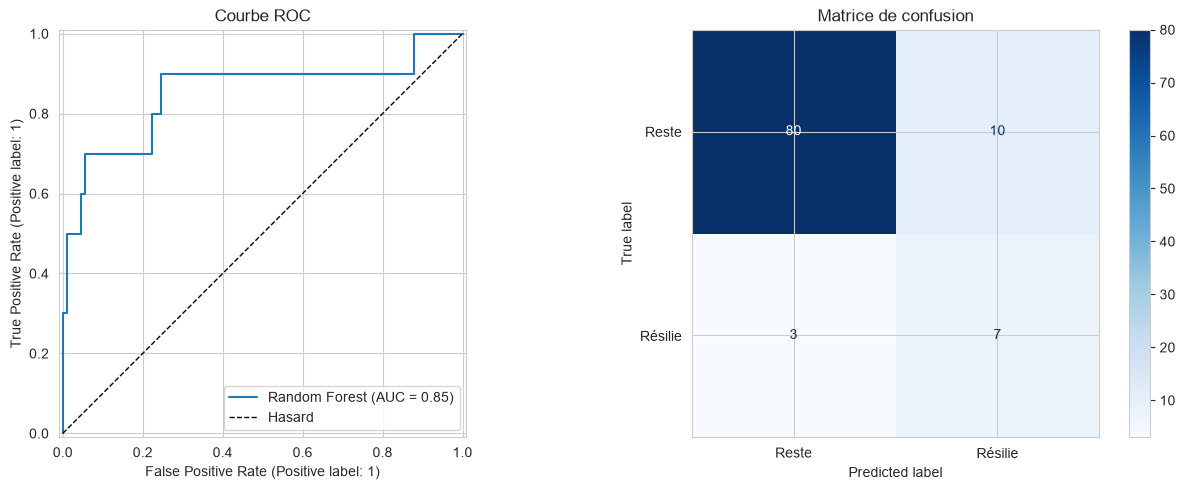

In [15]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0], name='Random Forest')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Hasard')
axes[0].set_title('Courbe ROC'); axes[0].legend()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Reste', 'Résilie'],
                                         cmap='Blues', ax=axes[1])
axes[1].set_title('Matrice de confusion')
plt.tight_layout(); plt.show()

## Étape 11 - Lire la matrice de confusion comme un métier

**Q1. Un modèle qui prédirait toujours « reste » aurait ~90 % d'accuracy. Est-il meilleur que le vôtre ?**

Non. Il afficherait une accuracy plus flatteuse mais détecterait **zéro** résiliation — c'est le piège
classique des classes déséquilibrées. Notre modèle sacrifie un peu d'accuracy globale pour détecter
une majorité des vrais résiliants, ce qui est précisément l'objectif métier.

**Q2. Quelle erreur coûte le plus cher : rater un partant (faux négatif) ou appeler un fidèle (faux positif) ?**

Le faux négatif coûte bien plus cher : un client perdu représente la perte de plusieurs années de
primes futures et un coût d'acquisition à refaire. Un faux positif ne coûte qu'un appel de courtoisie —
au pire perçu comme une attention du conseiller.

**Q3. Faut-il baisser ou monter le seuil de décision de 0,5 ?**

Le baisser. Un seuil plus bas classe plus de clients en « à risque », ce qui augmente le recall
(moins de résiliants ratés) au prix d'un F1/précision un peu plus faible. Puisque le faux négatif
coûte plus cher que le faux positif, ce compromis est favorable au métier. C'est exactement ce que
permet le curseur « Seuil d'alerte personnalisé » de l'application Streamlit.

---
# PARTIE C - Sauvegarde & interrogation du modèle

Objectif : un fichier .pkl + savoir lui poser une question.

## Étape 12 - Sauvegarder le pipeline complet

In [16]:
import joblib, os

joblib.dump(pipeline, 'models/pipeline_resiliation.pkl')
print(round(os.path.getsize('models/pipeline_resiliation.pkl') / 1024, 1), 'Ko')

493.7 Ko


## Étape 13 - Sauvegarder les métadonnées pour l'interface

In [17]:
import json

meta = {
    'modele': 'Random Forest',
    'auc_test': round(float(roc_auc_score(y_test, y_proba)), 3),
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'num_ranges': {c: {'min': float(X[c].min()), 'max': float(X[c].max()),
                       'median': float(X[c].median())} for c in num_cols},
    'cat_values': {c: sorted(X[c].unique().tolist()) for c in cat_cols},
    'proba_reference': [round(float(p), 4) for p in pipeline.predict_proba(X)[:, 1]],
}
with open('models/metadata.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print('Âge :', meta['num_ranges']['Âge'])
print('Type Contrat :', meta['cat_values']['Type Contrat'])

Âge : {'min': 18.0, 'max': 79.0, 'median': 50.0}
Type Contrat : ['Bronze', 'Gold', 'Platine', 'Silver']


> `ensure_ascii=False` est indispensable : sans lui, « Âge » serait écrit `\u00c2ge` dans le fichier
> et deviendrait illisible.

## Étape 14 - Interroger le modèle sur un nouveau client

In [18]:
# Rechargement du pipeline, comme si l'on repartait de zéro
modele = joblib.load('models/pipeline_resiliation.pkl')

client = pd.DataFrame([{
    'Âge': 34, 'Salaire Annuel (€)': 28000, 'Prime Annuelle (€)': 950,
    'Ancienneté (mois)': 6, 'Coeff. Bonus-Malus': 1.25, 'Nb Sinistres (3 ans)': 3,
    'Montant Sinistres (€)': 4200, 'Score Risque (0-100)': 72,
    'Type Contrat': 'Bronze', 'Catégorie Prof.': X['Catégorie Prof.'].iloc[0],
    'Usage Véhicule': X['Usage Véhicule'].iloc[0],
    'Dernier Sinistre': 'Vol' if 'Vol' in X['Dernier Sinistre'].unique() else X['Dernier Sinistre'].iloc[0],
}])

print('Classe :', modele.predict(client))
print('Proba  :', modele.predict_proba(client)[0, 1].round(3))

Classe : [1]
Proba  : 0.81


In [19]:
# Profil « fidèle » pour comparaison
client_fidele = client.copy()
client_fidele.loc[0, ['Ancienneté (mois)', 'Nb Sinistres (3 ans)', 'Montant Sinistres (€)',
                       'Score Risque (0-100)', 'Type Contrat', 'Dernier Sinistre']] = [
    200, 0, 0, 10, 'Gold', 'Aucun']

print('Classe :', modele.predict(client_fidele))
print('Proba  :', modele.predict_proba(client_fidele)[0, 1].round(3))

Classe : [0]
Proba  : 0.315


**Remarque :** on a donné des données BRUTES (texte, euros) - le pipeline a tout transformé seul
(normalisation + encodage), exactement comme il le fera pour les données saisies dans l'application.

## Étape 15 - Provoquer l'erreur classique, puis passer au script

In [20]:
try:
    modele.predict(client.drop(columns=['Score Risque (0-100)']))
except Exception as e:
    print('ERREUR :', e)

ERREUR : columns are missing: {'Score Risque (0-100)'}


**Règle pour l'interface :** fournir EXACTEMENT les 12 colonnes, avec les mêmes noms et le même ordre.
C'est exactement ce que garantit `pd.DataFrame([client])[num_cols + cat_cols]` dans `app.py`.

Le code des parties A, B et C a été regroupé dans **`train_model.py`**, exécutable en une seule
commande (`python train_model.py`) : c'est ce script qui recrée `pipeline_resiliation.pkl` et
`metadata.json` pour le déploiement.

---
## Synthèse - de ce notebook à l'application en ligne

| Étape | Où |
|---|---|
| Exploration et choix des variables | ce notebook (parties A-C) |
| Script reproductible | `train_model.py` |
| Modèle et métadonnées | `models/pipeline_resiliation.pkl`, `models/metadata.json` |
| Interface conseiller | `app.py` (Streamlit) |
| Mise en ligne | dépôt GitHub + Streamlit Community Cloud (voir `README.md`) |